In [1]:
from skimage.util import view_as_blocks

def split_patches(patch_size, image):
    blocks = view_as_blocks(image, block_shape=(patch_size, patch_size))
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [ ]:
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(400, 700),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)
    return dgms, vectors

In [3]:
def get_positions(image_data):

    blocks = view_as_blocks(image_data, block_shape=(16, 16))
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * 16, j * 16)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [4]:
import numpy as np

def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+16, c:c+16] = lab

    return label_img

In [5]:
import glob
import os
from ncempy.io import dm
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg

analysis_dataset = []

for dm3_file in glob.glob(os.path.join("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/", "*.dm3")):
    truth_image = dm3_file.replace("/2022_02_02 5nm Ag nanoparticles on UTC/", "/2022_02_02 5nm Ag nanoparticles on UTC/Labels/").replace(".dm3", "_label.png")
    truth_image = mpimg.imread(truth_image)

    print("Processing:", dm3_file)

    data_dict = dm.dmReader(str(Path(dm3_file).resolve()))
    image = data_dict['data']

    patched_image = split_patches(16, image)
    diagrams, vectorised_patches = PH_patch(patched_image)

    X = StandardScaler().fit_transform(vectorised_patches)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )

    embedding = reducer.fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42)
    labels = kmeans.fit_predict(embedding)

    positions = get_positions(image)
    label_img = label_to_image(image, labels, positions)

    mean_intensities = [image[label_img==cl].mean() for cl in np.unique(labels)]
    crystal_cluster = np.argmin(mean_intensities)

    mask = (label_img == crystal_cluster).astype(np.uint8)

    image_datapoint = {
        'original': image,
        'truth': truth_image,
        'diagrams': diagrams,
        'cluster_image': label_img,
        'mask': mask
    }
    analysis_dataset.append(image_datapoint)


import pickle

with open("topology_dataset.pkl", "wb") as f:
    pickle.dump(analysis_dataset, f) 


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_12.dm3


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_08.dm3


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing: ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_13.dm3


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


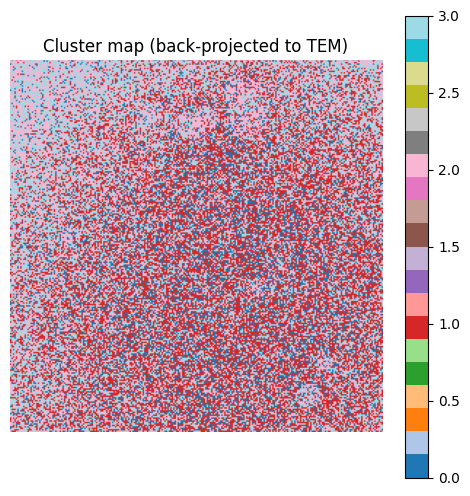

In [28]:
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

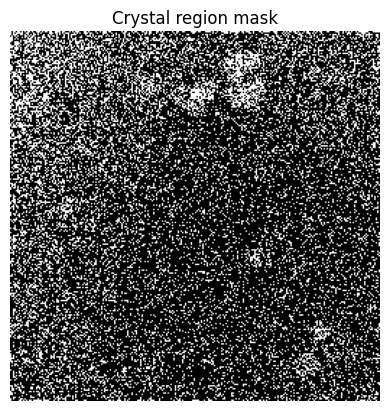

In [30]:
mean_intensities = [image[label_img==cl].mean() for cl in np.unique(labels)]
crystal_cluster = np.argmin(mean_intensities)

mask = (label_img == crystal_cluster).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show() 


In [6]:
with open("topology_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

In [7]:
import numpy as np
from sklearn.metrics import pairwise_distances
from persim import PersImage

patch_h = 16 
patch_w = 16
cluster_medoid_pds_per_image = []
crystalline_clusters_per_image = []

for sample in dataset:
    print(sample['original'].min())

    # Repatch cluster image to get per-patch labels
    cluster_image = sample["cluster_image"]  # H x W, integer labels
    cluster_patches = split_patches(16,cluster_image)
    print('repatch')
    # Extract per-patch cluster labels (assuming each patch uniform)
    cluster_labels = [int(p[0,0]) for p in cluster_patches]
    
    # Align PDs with cluster labels
    patch_pds = sample["diagrams"]  # same order as patches
    assert len(cluster_labels) == len(patch_pds), "Mismatch: PDs and cluster patches"

    all_patch_data = [
        {"pd": pd, "cluster": cl, "patch_array": patch}
        for pd, cl, patch in zip(patch_pds, cluster_labels, cluster_patches)
    ]
    print('datamade')

    # Compute mean intensity per cluster to identify crystalline cluster
    cluster_mean_intensity = {}
    for c in set(cluster_labels):
        cluster_mean_intensity[c] = np.mean([
            d["patch_array"].mean() for d in all_patch_data if d["cluster"] == c
        ])
    crystalline_cluster = min(cluster_mean_intensity, key=cluster_mean_intensity.get)
    crystalline_clusters_per_image.append(crystalline_cluster)
    print(crystalline_cluster)
    
    for c in set(cluster_labels):
        vecs = np.array([
            pimgr.transform(d["pd"]).ravel()
            for d in all_patch_data
            if d["cluster"] == c
        ])

        centroid = vecs.mean(axis=0)

        idx = np.argmin(np.linalg.norm(vecs - centroid, axis=1))

        representative_pd = [
            d["pd"] for d in all_patch_data if d["cluster"] == c
        ][idx]    

    cluster_medoid_pds_per_image.append(representative_pd)
    sample["patch_clusters"] = cluster_labels
    print('next')


0.0
repatch
datamade
0


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Loop over images
for img_idx, (medoid_dict, crystalline_cluster) in enumerate(
        zip(cluster_medoid_pds_per_image, crystalline_clusters_per_image)):

    clusters = sorted(medoid_dict.keys())
    n_clusters = len(clusters)

    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]  # handle single cluster case

    for ax, c in zip(axes, clusters):
        pd = medoid_dict[c]
        ax.scatter(pd[:,0], pd[:,1], 
                   color='red' if c == crystalline_cluster else 'blue')
        ax.set_title(f"Cluster {c} {'(crystalline)' if c==crystalline_cluster else ''}")
        ax.set_xlabel("Birth")
        ax.set_ylabel("Death")
        ax.set_aspect('equal')

    fig.suptitle(f"Image {img_idx} Medoid PDs", fontsize=16)
    plt.tight_layout()
    plt.show()